<a href="https://colab.research.google.com/github/Prudycruise/nhs-healthcare-analytics/blob/main/python/01_data_inspection.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [86]:
import pandas as pd

url = "https://raw.githubusercontent.com/Prudycruise/nhs-healthcare-analytics/main/data/raw/AE_attendances_england_monthly.csv"

df = pd.read_csv(url)

print("Dataset loaded successfully")
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

df.head()

Dataset loaded successfully
Rows: 27112
Columns: 20


,Unnamed: 0,date,Name,Type 1 Departments - Major A&E,Type 2 Departments - Single Specialty,Type 3 Departments - Other A&E/Minor Injury Unit,Total attendances,Type 1 Departments - 4 hours to decision,Type 2 Departments - 4 hours to decision,Type 3 Departments - 4 hours to decision,Percentage in 4 hours or less (all),Emergency Admissions via Type 1 A&E in 4 hours,Emergency Admissions via Type 2 A&E in 4 hours,Emergency Admissions via Type 3 and 4 A&E in 4 hours,Other Emergency admissions (i.e not via A&E),Number of patients spending >12 hours from decision to admit to admission,month,year,lat,lon
0,0,2010-11-01,Aintree University Hospitals NHS Foundation Trust,4622.0,0.0,0.0,4622.0,7.0,0.0,0.0,2.995435,1406.0,0.0,0.0,530.0,0.0,44.0,8040.0,53.461606,-2.943427
1,1,2010-11-01,Airedale NHS Trust,3965.0,0.0,0.0,3965.0,65.0,0.0,0.0,3.934107,892.0,0.0,0.0,568.0,0.0,44.0,8040.0,NaN,NaN
2,2,2010-11-01,Alder Hey Children’S NHS Foundation Trust,4541.0,0.0,0.0,4541.0,71.0,0.0,0.0,3.937936,1825.0,0.0,0.0,270.0,0.0,44.0,8040.0,50.183000,-5.416000
3,3,2010-11-01,Ashford And St Peter'S Hospitals NHS Trust,7010.0,0.0,769.0,7779.0,392.0,0.0,0.0,3.797332,1902.0,0.0,0.0,163.0,0.0,44.0,8040.0,51.655000,-0.395694
4,4,2010-11-01,"Ashton, Leigh And Wigan Primary Care Trust",0.0,0.0,4297.0,4297.0,0.0,0.0,0.0,4.000000,0.0,0.0,0.0,0.0,0.0,44.0,8040.0,51.272000,0.529000


In [87]:
print("Column names:")

for column in df.columns:
    print(column)

Column names:
Unnamed: 0
date
Name
Type 1 Departments - Major A&E
Type 2 Departments - Single Specialty
Type 3 Departments - Other A&E/Minor Injury Unit
Total attendances
Type 1 Departments - 4 hours to decision
Type 2 Departments - 4 hours to decision
Type 3 Departments - 4 hours to decision
Percentage in 4 hours or less (all)
Emergency Admissions via Type 1 A&E in 4 hours
Emergency Admissions via Type 2 A&E in 4 hours
Emergency Admissions via Type 3 and 4 A&E in 4 hours
Other Emergency admissions (i.e not via A&E)
Number of patients spending >12 hours from decision to admit to admission
month
year
lat
lon


In [88]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 27112 entries, 0 to 27111
Data columns (total 20 columns):
 #   Column                                                                     Non-Null Count  Dtype  
---  ------                                                                     --------------  -----  
 0   Unnamed: 0                                                                 27112 non-null  int64  
 1   date                                                                       27112 non-null  str    
 2   Name                                                                       27108 non-null  str    
 3   Type 1 Departments - Major A&E                                             27112 non-null  float64
 4   Type 2 Departments - Single Specialty                                      27112 non-null  float64
 5   Type 3 Departments - Other A&E/Minor Injury Unit                           27112 non-null  float64
 6   Total attendances                                                

In [89]:
missing_values = df.isnull().sum()

print("Missing values:")
print(missing_values[missing_values > 0])

Missing values:
Name       4
lat     8010
lon     8010
dtype: int64


In [90]:
print("Duplicate rows:", df.duplicated().sum())

Duplicate rows: 0


In [91]:
df["date"] = pd.to_datetime(df["date"], errors="coerce")

print("Earliest date:", df["date"].min())
print("Latest date:", df["date"].max())
print("Invalid dates:", df["date"].isnull().sum())

Earliest date: 2010-11-01 00:00:00
Latest date: 2020-06-01 00:00:00
Invalid dates: 0


In [92]:
incorrect_months = df[df["month"] != df["date"].dt.month]
incorrect_years = df[df["year"] != df["date"].dt.year]

print("Rows with incorrect months:", len(incorrect_months))
print("Rows with incorrect years:", len(incorrect_years))

Rows with incorrect months: 12320
Rows with incorrect years: 12320


In [93]:
percentage_column = "Percentage in 4 hours or less (all)"

print(df[percentage_column].describe())
print()
print("Values above 100%:", (df[percentage_column] > 1).sum())

count    27112.000000
mean         2.234394
std          1.665038
min          0.000000
25%          0.910265
50%          1.000000
75%          3.941170
max          5.000000
Name: Percentage in 4 hours or less (all), dtype: float64

Values above 100%: 11792


## Initial Data Quality Findings

- The dataset contains 27,112 rows and 20 columns.
- The date range runs from November 2010 to June 2020.
- The `Unnamed: 0` column appears to be an unnecessary index.
- Some organisation names are missing.
- Many latitude and longitude values are missing.
- Some month and year values do not match the date.
- Some four-hour performance values exceed 100%.
- Suspicious records require investigation before analysis.
- The raw dataset will remain unchanged.

## Analysis Questions

1. How did total A&E attendance change over time?
2. Which NHS organisations recorded the highest total attendance?
3. How did attendance differ between Type 1, Type 2 and Type 3 departments?
4. How did four-hour performance change over time?
5. Which organisations recorded the highest numbers of patients waiting longer than 12 hours?

## 1. NHS Organisations with the Highest Total Attendances

In [94]:
# Total A&E attendances by NHS organisation
organisation_attendance = (
    df.groupby("Name")["Total attendances"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

organisation_attendance

Name
Barts Health NHS Trust                                            3609754.0
Pennine Acute Hospitals NHS Trust                                 2986133.0
Imperial College Healthcare NHS Trust                             2478290.0
Barking, Havering And Redbridge University Hospitals NHS Trust    2331185.0
King's College Hospital NHS Foundation Trust                      2205103.0
County Durham And Darlington NHS Foundation Trust                 2191354.0
Leeds Teaching Hospitals NHS Trust                                2097985.0
Mid Yorkshire Hospitals NHS Trust                                 2056134.0
University Hospitals Of Leicester NHS Trust                       1996999.0
Lewisham And Greenwich NHS Trust                                  1957339.0
Name: Total attendances, dtype: float64

In [95]:
import matplotlib.pyplot as plt

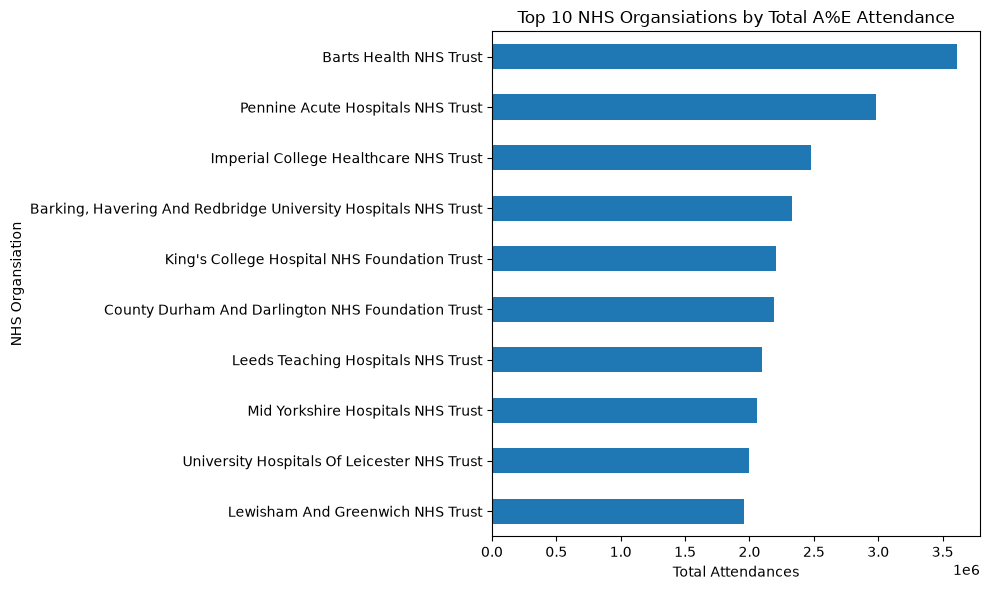

In [96]:
organisation_attendance.sort_values().plot(
    kind="barh",
    figsize=(10, 6),
    title="Top 10 NHS Organsiations by Total A%E Attendance"
)

plt.xlabel("Total Attendances")
plt.ylabel("NHS Organsiation")
plt.tight_layout()
plt.show()

## 2. Total A%E Attendance Over Time

In [97]:
attendance_over_time = (
    df.groupby("date")["Total attendances"]
    .sum()
    .sort_index()
)

attendance_over_time.head()

date
2010-11-01    1547196.0
2010-12-01    1539219.0
2011-01-01    1972266.0
2011-02-01    1600371.0
2011-03-01    1670444.0
Name: Total attendances, dtype: float64

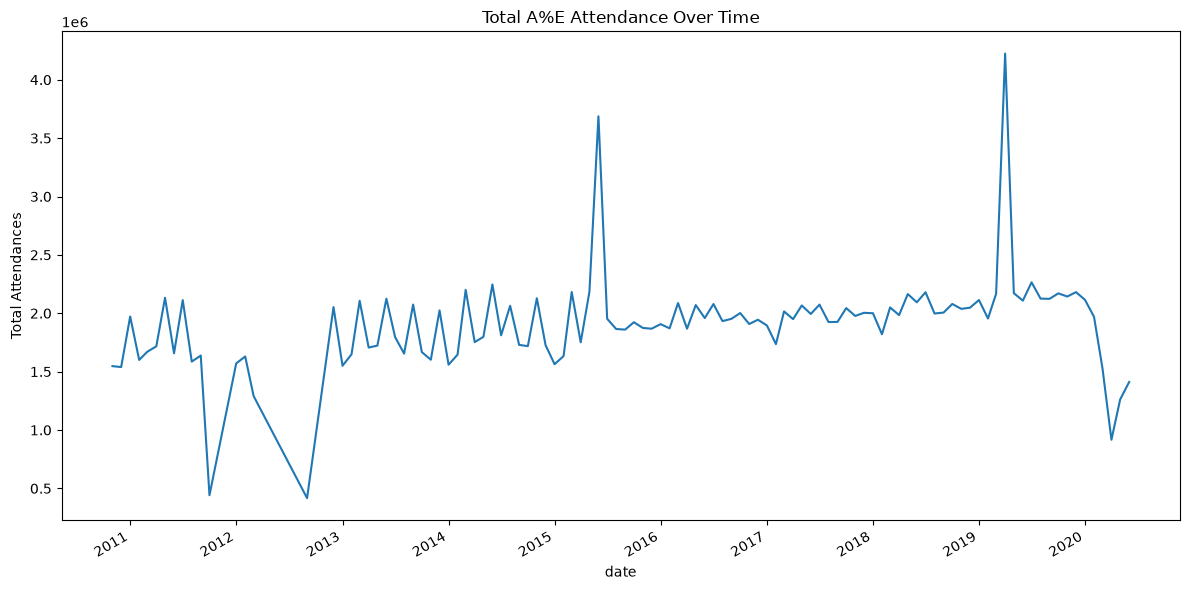

In [98]:
attendance_over_time.plot(
    kind="line",
    figsize=(12, 6),
    title="Total A%E Attendance Over Time"
)

plt.xlabel("date")
plt.ylabel("Total Attendances")
plt.tight_layout()
plt.show()

### Investigating Unusual Attendance Values

In [99]:
attendance_over_time.sort_values(ascending=False).head(10)

date
2019-04-01    4224286.0
2015-06-01    3687103.0
2019-07-01    2265050.0
2014-06-01    2246955.0
2014-03-01    2200193.0
2015-05-01    2185130.0
2015-03-01    2182129.0
2019-12-01    2181024.0
2018-07-01    2179896.0
2019-05-01    2172022.0
Name: Total attendances, dtype: float64

In [100]:
april_2019 = df[df["date"] == "2019-04-01"]

april_2019[
    ["Name", "Total attendances"]
    ].sort_values(
        "Total attendances",
        ascending=False
    ).head(10)

,Name,Total attendances
23688,Barts Health NHS Trust,85576.0
23779,Manchester University NHS Foundation Trust,69820.0
23883,University Hospitals Birmingham NHS Foundation...,68902.0
23817,Pennine Acute Hospitals NHS Trust,67804.0
23775,London North West University Healthcare NHS Trust,61482.0
23886,University Hospitals Of Derby And Burton NHS F...,56302.0
23709,Chelsea And Westminster Hospital NHS Foundatio...,54820.0
23686,"Barking, Havering And Redbridge University Hos...",51236.0
23771,Lewisham And Greenwich NHS Trust,51022.0
23760,Imperial College Healthcare NHS Trust,48540.0


In [101]:
monthly_record_counts = df.groupby("date").size().sort_values(ascending=False)

monthly_record_counts.head(10)

date
2011-01-01    419
2011-04-01    382
2010-12-01    321
2011-03-01    320
2011-02-01    317
2010-11-01    298
2011-05-01    297
2011-06-01    295
2011-07-01    293
2011-08-01    285
dtype: int64

In [102]:
monthly_record_counts.loc["2019-03-01":"2019-05-01"]

KeyError: 'Value based partial slicing on non-monotonic DatetimeIndexes with non-existing keys is not allowed.'

In [ ]:
df[df["date"].between("2019-03-01", "2019-05-01")].groupby("date").size()

In [ ]:
april_2019.duplicated().sum()

In [ ]:
april_2019["Name"].value_counts().head(10)

In [ ]:
df.columns.tolist()

In [103]:
april_2019 = april_2019.copy()

april_2019["Calculated Total"] = (
    april_2019["Type 1 Departments - Major A&E"]
    + april_2019["Type 2 Departments - Single Specialty"]
    + april_2019["Type 3 Departments - Other A&E/Minor Injury Unit"]
)

april_2019["Difference"] = (
    april_2019["Total attendances"]
    - april_2019["Calculated Total"]
)

april_2019[
    ["Name", "Total attendances", "Calculated Total", "Difference"]
].sort_values("Difference", ascending=False).head(10)

,Name,Total attendances,Calculated Total,Difference
23678,Aintree University Hospital NHS Foundation Trust,16444.0,16444.0,0.0
23679,Airedale NHS Foundation Trust,11808.0,11808.0,0.0
23680,Alder Hey Children's NHS Foundation Trust,9864.0,9864.0,0.0
23681,Ashford And St Peter's Hospitals NHS Foundatio...,18732.0,18732.0,0.0
23682,Ashford Walk-In-Centre,7442.0,7442.0,0.0
23683,Assura Reading Llp,6372.0,6372.0,0.0
23684,Assura Vertis Urgent Care Centres (Birmingham),12468.0,12468.0,0.0
23685,Badger Ltd,6382.0,6382.0,0.0
23686,"Barking, Havering And Redbridge University Hos...",51236.0,51236.0,0.0
23687,Barnsley Hospital NHS Foundation Trust,17452.0,17452.0,0.0


### Anomaly Investigation Findings

The attendance trend showed unusually high totals in April 2019 and June 2015.

Further investigation of April 2019 found that:

- The month contained 234 records, similar to March (225) and May (231).
- No exact duplicate records were identified.
- Each organisation appeared only once.
- Individual organisation attendance values did not show a single extreme value large enough to explain overall spike.
- Reported total attendance matched the sum of Type 1, type 2 and Type 3 attendance values for the inspected records.

Therefore, the April 2019 spike cannot be explained by obvious duplication, record-count differences or inconsistent attendance totals. Further investigation would be required before attributing the spike to changes in healthcare demand.

## 3. Attendance by A&E Department Type